# PCA on the latent space of the autoencoder (OASIS3 data) without retraining

In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns

In [2]:
class AE(nn.Module):
    def __init__(self, input_size, latent_size):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # encoder network
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )
        # decoder network
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)
        
#load trained model
def load_model(input_size, latent_size):
    model = AE(input_size=input_size, latent_size=latent_size)
    model.load_state_dict(
        torch.load("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/best_autoencoder.pt")
    )
    model.eval()
    return model
model = load_model(103,10)

In [3]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data"
df_ae = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/csv_files/Oasis3_data.csv")
df_orig = pd.read_csv(os.path.join(path, "Final_data.csv"))


#these cols had only zeros (left-vessel had 0s in some cases but not all --> may fit a separate model for this)
df_orig = df_orig.drop(columns=
                   ['Unnamed: 0','5th-Ventricle',
                    'Left-WM-hypointensities',
                    'Left-non-WM-hypointensities',
                    'Left-vessel','Left-WM-hypointensities',
                    'Left-non-WM-hypointensities','Right-WM-hypointensities',
                    'Right-non-WM-hypointensities', 'non-WM-hypointensities','SubjectID','Year_initial_scan',
                     'Sex','Birthyear','Age','Site','Left-Thalamus-Proper', 'Right-Thalamus-Proper', 'Left-Thalamus', 'Right-Thalamus'])

df_ae  = df_ae.drop(columns=
                   ['Unnamed: 0','5th-Ventricle',
                    'Left-WM-hypointensities',
                    'Left-non-WM-hypointensities',
                    'Left-vessel','Left-WM-hypointensities',
                    'Left-non-WM-hypointensities','Right-WM-hypointensities',
                    'Right-non-WM-hypointensities', 'non-WM-hypointensities','SubjectID',
                   'lh_G_front_inf-Opercular_thickness'])

pd.set_option('display.max_columns', None)


first_cols = ["Age", "Sex", "Site", "Diagnosis"]
other_cols = df_ae.columns.difference(first_cols, sort=False)
df_ae = df_ae[first_cols + list(other_cols)]
df = df_ae.iloc[:,:4]
df_ae = df_ae.iloc[:,4:]

# df_orig = df_orig.iloc[:,1:]
# set_df_orig = set(df_orig)
# set_df_ae = set(df_ae)
# in_orig = set_df_orig.difference(set_df_ae)
# in_ae = set_df_ae.difference(set_df_orig)

# print(in_orig)
# print(in_ae)

#ensure the ordering is the same for the trained autoencoder and the 
df_orig_ordering = list(df_orig.columns)
df_orig_ordering
df_ae = df_ae[df_orig_ordering]
df_ae

,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,lh_G_oc-temp_med-Parahip_thickness,lh_G_occipital_middle_thickness,lh_G_orbital_thickness,lh_G_pariet_inf-Angular_thickness,lh_G_pariet_inf-Supramar_thickness,lh_G_parietal_sup_thickness,lh_G_postcentral_thickness,lh_G_precentral_thickness,lh_G_rectus_thickness,lh_G_temp_sup-Lateral_thickness,lh_G_temp_sup-Plan_tempo_thickness,lh_G_temporal_inf_thickness,lh_G_temporal_middle_thickness,lh_Pole_occipital_thickness,lh_Pole_temporal_thickness,lh_S_calcarine_thickness,lh_S_central_thickness,lh_S_collat_transv_ant_thickness,lh_S_front_inf_thickness,lh_S_front_middle_thickness,lh_S_front_sup_thickness,lh_S_occipital_ant_thickness,lh_S_orbital-H_Shaped_thickness,lh_S_pericallosal_thickness,lh_S_postcentral_thickness,lh_S_precentral-inf-part_thickness,lh_S_precentral-sup-part_thickness,lh_S_temporal_inf_thickness,lh_S_temporal_sup_thickness,rh_G_cuneus_thickness,rh_G_front_middle_thickness,rh_G_front_sup_thickness,rh_G_oc-temp_lat-fusifor_thickness,rh_G_occipital_middle_thickness,rh_G_occipital_sup_thickness,rh_G_orbital_thickness,rh_G_pariet_inf-Angular_thickness,rh_G_pariet_inf-Supramar_thickness,rh_G_parietal_sup_thickness,rh_G_postcentral_thickness,rh_G_precentral_thickness,rh_G_precuneus_thickness,rh_G_temp_sup-Lateral_thickness,rh_G_temp_sup-Plan_tempo_thickness,rh_G_temporal_inf_thickness,rh_G_temporal_middle_thickness,rh_Pole_occipital_thickness,rh_S_calcarine_thickness,rh_S_central_thickness,rh_S_cingul-Marginalis_thickness,rh_S_front_inf_thickness,rh_S_front_middle_thickness,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,CC_Mid_Anterior,CC_Mid_Posterior,CC_Posterior,CSF,Left-Accumbens-area,Left-Amygdala,Left-Caudate,Left-Cerebellum-Cortex,Left-Cerebellum-White-Matter,Left-Hippocampus,Left-Inf-Lat-Vent,Left-Lateral-Ventricle,Left-Pallidum,Left-Putamen,Left-VentralDC,Left-choroid-plexus,Optic-Chiasm,Right-Accumbens-area,Right-Amygdala,Right-Caudate,Right-Cerebellum-Cortex,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
0,2.370,2.500,2.850,2.674,2.005,3.281,2.611,2.622,2.462,2.658,2.413,1.995,2.732,2.371,3.220,2.739,3.027,2.926,2.237,3.692,1.734,1.918,2.528,2.260,2.186,2.420,2.423,2.764,2.388,2.126,2.473,2.565,2.443,2.394,1.827,2.379,2.767,2.763,2.558,2.193,2.501,2.637,2.625,2.441,2.123,2.707,2.640,3.083,2.497,2.918,2.951,1.980,1.784,1.916,2.310,2.220,2.149,2.286,2.457,2.532,2.573,2.306,2.220,2.152,2.330,2.357,2.424,743.3,1461.3,21397.6,782.3,512.0,478.5,485.7,885.7,823.2,400.8,1450.8,3030.6,44219.8,15701.3,3750.8,346.9,5436.4,985.4,4515.9,3496.6,1056.4,164.8,467.5,1385.8,2874.8,44602.1,16298.9,3928.1,409.4,3741.7,1405.4,4404.8,3693.3,1178.1,57.9,1121.8
1,2.286,2.371,2.751,2.684,1.930,3.399,2.619,2.623,2.438,2.643,2.263,2.041,2.661,2.412,3.165,2.546,2.965,2.960,2.186,3.541,1.662,1.943,2.379,2.041,1.923,2.241,2.399,2.601,2.323,2.001,2.363,2.330,2.347,2.382,1.737,2.227,2.694,2.776,2.680,2.117,2.613,2.366,2.307,2.315,1.929,2.424,2.441,3.026,2.159,3.004,2.859,1.886,1.636,1.687,2.238,1.987,1.944,2.225,2.270,2.655,2.572,2.097,2.394,1.926,2.215,2.282,2.227,750.8,1242.4,21289.2,767.5,473.2,491.0,496.8,870.1,858.0,279.9,1510.7,2944.1,44712.0,16010.6,3698.6,318.0,5601.5,786.1,4228.2,3282.3,1188.8,174.2,480.9,1368.4,2856.1,45128.6,16260.2,3949.6,331.5,3814.2,1349.4,4328.1,3306.7,1594.6,48.2,1297.5
2,2.291,2.364,2.667,2.605,1.996,3.255,2.545,2.510,2.405,2.516,2.263,2.005,2.571,2.088,2.928,2.340,2.864,2.790,2.219,3.367,1.692,1.895,2.407,2

In [3]:
#this is the cleaned up version of the code below (with the final data)
df_ae  = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data/Full_Dataset_UKB_ADNI_OASIS3.csv")
df_ae = df_ae.iloc[:,1:]
df_ae = df_ae[df_ae["Dataset"] != "UKB"]
df_demo = df_ae.iloc[:,:5]
df_ae = df_ae.iloc[:,5:]
df_demo = df_demo.reset_index(drop=True)
df_demo

,Age,Sex,Site,Diagnosis,Dataset
0,85.0,1.0,2.0,0.0,ADNI
1,76.0,0.0,2.0,0.0,ADNI
2,79.0,1.0,2.0,0.0,ADNI
3,90.0,0.0,2.0,0.0,ADNI
4,65.0,0.0,2.0,1.0,ADNI
...,...,...,...,...,...
3036,72.0,1.0,403.0,0.0,OASIS3
3037,65.0,0.0,401.0,0.0,OASIS3
3038,71.0,0.0,401.0,1.0,OASIS3
3039,72.0,0.0,401.0,0.0,OASIS3


In [4]:
#original data data
scaler = RobustScaler()
data_scaled = scaler.fit_transform(df_ae)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
tensor_dataset = TensorDataset(data_tensor)

In [5]:
#encode data
with torch.no_grad():
    latent_representations = model.encode(data_tensor).numpy()

df_latents = pd.DataFrame(latent_representations)

pca = PCA(n_components=10)
latent_pca = pca.fit_transform(latent_representations) 

#make dataframes and concat
latent_pca_df = pd.DataFrame(latent_pca).reset_index(drop=True)
latent_pca_df
latent_pca_df_asl = latent_pca_df.join(df_demo)

latent_pca_df_asl
latent_pca_df_asl = latent_pca_df_asl.rename(columns={i: f"PC{1+i}" for i in range(latent_pca.shape[1])})
latent_pca_df_asl["Diagnosis"] = df_demo["Diagnosis"]
latent_pca_df_asl 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Age,Sex,Site,Diagnosis,Dataset
0,0.149282,-1.648033,0.003598,0.070990,-1.602253,0.216195,-0.770581,-0.078870,0.602158,-0.469026,85.0,1.0,2.0,0.0,ADNI
1,0.147685,-0.960642,-0.230944,-0.406641,0.484497,-0.566524,-0.689286,0.191155,-0.039826,-0.174489,76.0,0.0,2.0,0.0,ADNI
2,0.259791,0.140005,-0.899871,-0.511771,0.287107,-0.209168,-0.905064,0.012956,0.917668,0.502845,79.0,1.0,2.0,0.0,ADNI
3,-3.396837,2.182404,2.029336,-1.415420,-1.724000,0.337802,-0.031917,0.554650,-0.151311,0.200274,90.0,0.0,2.0,0.0,ADNI
4,0.092264,-0.370964,0.925181,0.254212,0.267778,1.249086,-0.398490,-0.090055,-0.340609,-0.461088,65.0,0.0,2.0,1.0,ADNI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3036,-0.493064,-0.774255,0.797448,-0.259119,0.839990,-0.754564,0.365365,-0.822780,0.281741,-0.017769,72.0,1.0,403.0,0.0,OASIS3
3037,-0.434363,-2.099674,-0.256146,0.094779,-1.343178,-0.796761,-1.056650,-0.377277,-0.215586,-0.394361,65.0,0.0,401.0,0.0,OASIS3
3038,-0.599503,-1.317412,-0.451849,0.333628,1.180786,0.143327,-0.005337,-0.209248,-0.585559,0.318463,71.0,0.0,401.0,1.0,OASIS3
3039,-0.015691,0.410064,-1.065644,-0.015805,0.688984,-0.538955,-0.378446,-0.022063,-0.398265,0.130020,72.0,0.0,401.0,0.0,OASIS3


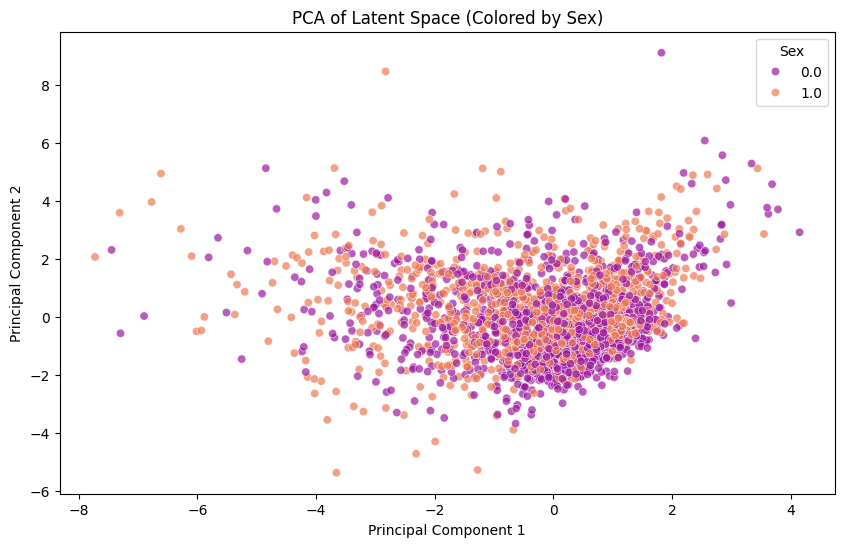

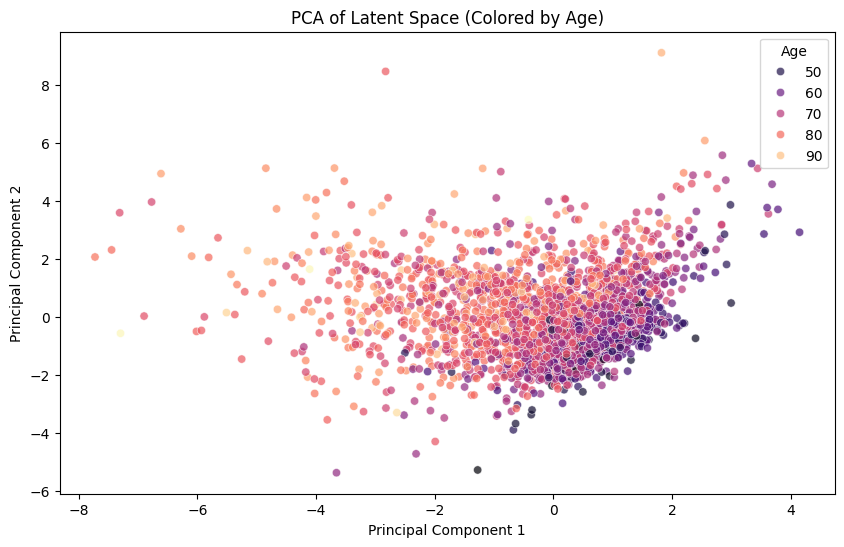

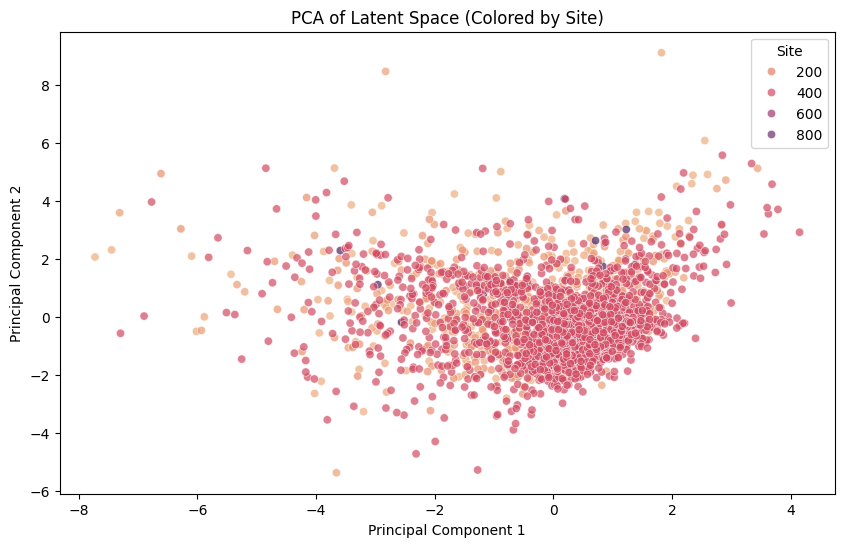

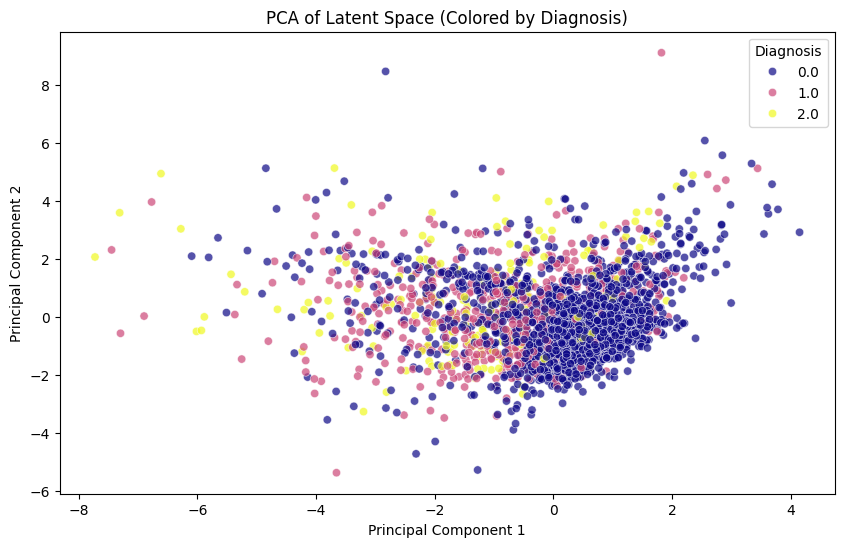

In [6]:

#sex figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Sex",
    palette="plasma",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Sex)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Sex")
plt.show()

#age figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Age",
    palette="magma",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Age)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Age")
plt.show()

#site figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Site",
    palette="flare",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Site)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Site")
plt.show()


#diagnosis figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette="plasma",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Diagnosis)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Diagnosis")
plt.show()


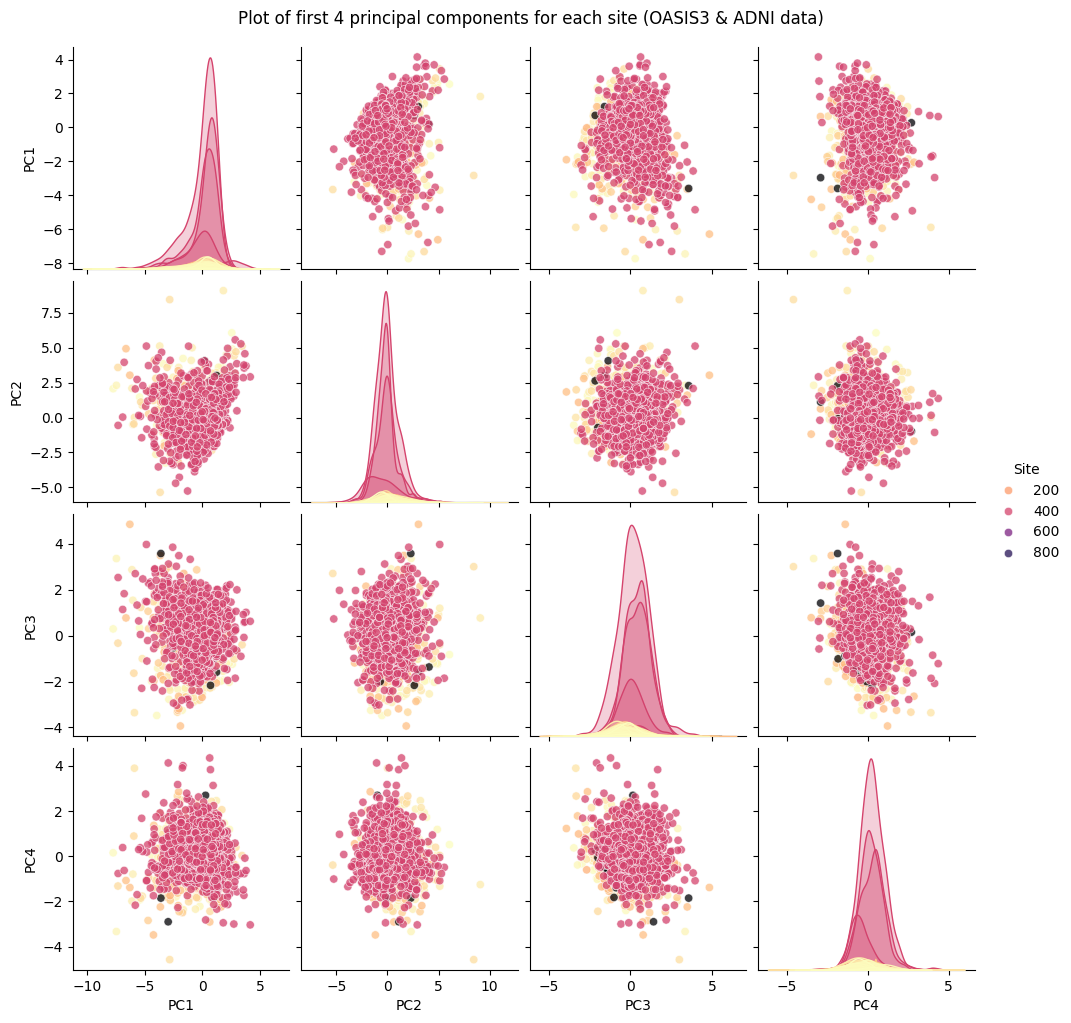

In [13]:
pca_df = pd.DataFrame(latent_pca_df_asl, columns=['PC1', 'PC2', 'PC3', 'PC4','Age','Sex','Site', 'Diagnosis'])

min_age = pca_df["Age"].min()
max_age = pca_df["Age"].max()
bins = np.arange(np.floor(min_age / 5) * 5, np.ceil(max_age / 5) * 5 + 1, 5)
pca_df['AgeGroup'] = pd.cut(
    pca_df['Age'],
    bins=bins,
    labels = [f"{int(bins[i])}-{int(bins[i+1]-1)}" for i in range(len(bins)-1)],
    right=False
)

# # plot for age
# sns.pairplot(pca_df, hue="AgeGroup", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
# plt.suptitle('Plot of first 4 principal components for each age group (OASIS3 & ADNI data)', y=1.02)
# plt.show()


# # plot for sex
# sns.pairplot(pca_df, hue="Sex", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
# plt.suptitle('Plot of first 4 principal components for each sex (OASIS3 & ADNI data)', y=1.02)
# plt.show()

# plot for site
sns.pairplot(pca_df, hue="Site", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="magma_r", plot_kws=dict(alpha=0.75))
plt.suptitle('Plot of first 4 principal components for each site (OASIS3 & ADNI data)', y=1.02)
plt.show()

# # plot for diagnosis
# sns.pairplot(pca_df, hue="Diagnosis", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma_r", plot_kws=dict(alpha=0.3))
# plt.suptitle('Plot of first 4 principal components for each diagnosis (OASIS3 & ADNI data)', y=1.02)
# plt.show()


Diagnosis
0.0    1972
1.0     820
2.0     249
Name: count, dtype: int64


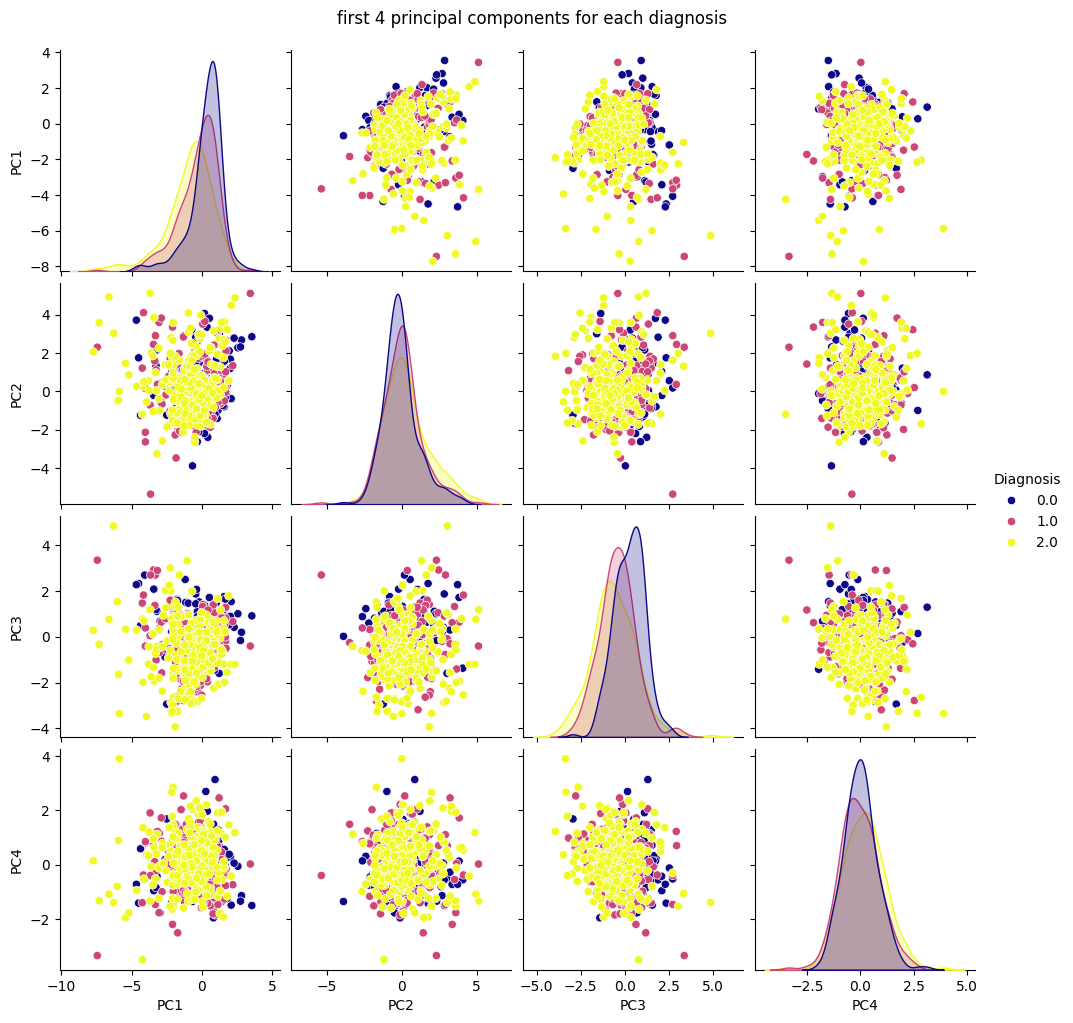

In [55]:
diagnosis_counts = pca_df['Diagnosis'].value_counts()
print(diagnosis_counts)
min_samples = diagnosis_counts.min()

# downsample the healthy controls
balanced_df = pd.DataFrame()
for diagnosis, count in diagnosis_counts.items():
    sampled = pca_df[pca_df['Diagnosis'] == diagnosis].sample(min_samples, random_state=42)
    balanced_df = pd.concat([balanced_df, sampled])

sns.pairplot(balanced_df, hue="Diagnosis", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
plt.suptitle('first 4 principal components for each diagnosis', y=1.02)
plt.show()

PC1:    Cummulative variance:  24.79%,  Individual variance:  24.79%
PC2:    Cummulative variance:  46.15%,  Individual variance:  21.36%
PC3:    Cummulative variance:  58.78%,  Individual variance:  12.63%
PC4:    Cummulative variance:  68.58%,  Individual variance:  9.80%
PC5:    Cummulative variance:  77.71%,  Individual variance:  9.14%
PC6:    Cummulative variance:  83.91%,  Individual variance:  6.20%
PC7:    Cummulative variance:  88.96%,  Individual variance:  5.05%
PC8:    Cummulative variance:  93.05%,  Individual variance:  4.09%
PC9:    Cummulative variance:  96.86%,  Individual variance:  3.81%
PC10:   Cummulative variance:  100.00%,  Individual variance:  3.14%


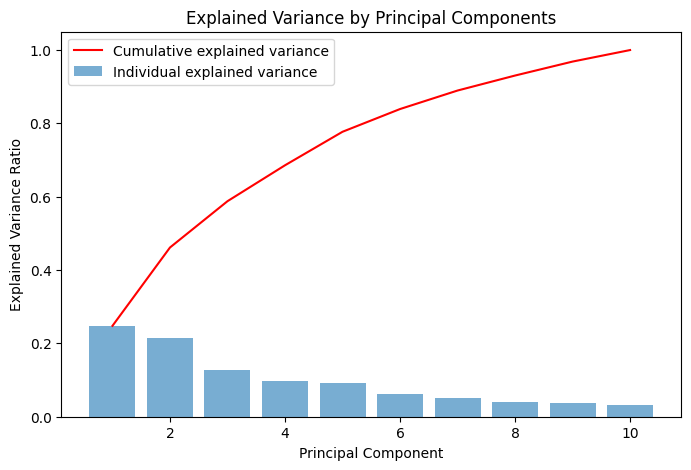

In [56]:
cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'r-', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.show()